In [13]:
# Notebook 01: Cifrado por Sustitución y César

### Celda 1: Librerías y alfabeto
import string
import matplotlib.pyplot as plt
from collections import Counter

# Alfabeto para trabajar en mayúsculas sin espacios ni tildes
ALPHABET = string.ascii_uppercase

In [14]:
### Celda 2: Funciones de cifrado y descifrado

def cifrado_cesar(texto, desplazamiento):
    resultado = ""
    texto = texto.upper()
    for letra in texto:
        if letra in ALPHABET:
            indice = (ALPHABET.index(letra) + desplazamiento) % 26
            resultado += ALPHABET[indice]
        else:
            resultado += letra  # Mantener espacios o puntuación
    return resultado

def descifrado_cesar(texto, desplazamiento):
    return cifrado_cesar(texto, -desplazamiento)

In [31]:
### Celda 3: Ejemplo básico
texto_original = "Introduccion a la criptografia con aplicaciones practicas"
desplazamiento = 2

cifrado = cifrado_cesar(texto_original, desplazamiento)
descifrado = descifrado_cesar(cifrado, desplazamiento)

print(f"Texto original : {texto_original}")
print(f"Texto cifrado  : {cifrado}")
print(f"Texto descifrado: {descifrado}")


Texto original : Introduccion a la criptografia con aplicaciones practicas
Texto cifrado  : KPVTQFWEEKQP C NC ETKRVQITCHKC EQP CRNKECEKQPGU RTCEVKECU
Texto descifrado: INTRODUCCION A LA CRIPTOGRAFIA CON APLICACIONES PRACTICAS


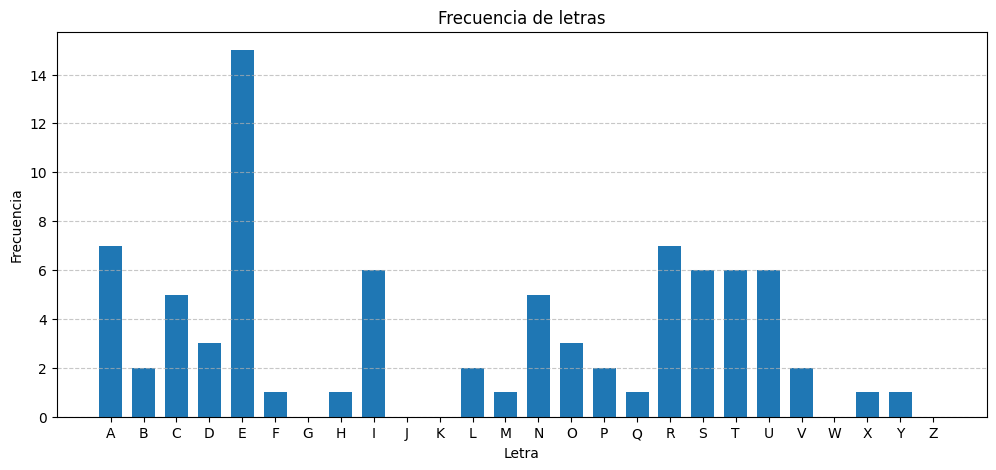

In [8]:

### Celda 7: Análisis de frecuencia
%matplotlib inline
def graficar_frecuencia(texto):
    texto = texto.upper()
    solo_letras = [c for c in texto if c in ALPHABET]
    conteo = Counter(solo_letras)
    Alfabeto = ["A","B","C","D","E","F","G","H","I","J","K","L","M","N","O","P","Q","R","S","T","U","V","W","X","Y","Z",]

    # Mostrar el conteo por consola (opcional pero útil para depurar)
    # print("Conteo de letras:")
    # for letra in ALPHABET:
    #     if conteo.get(letra, 0) > 0:
    #         print(f"{letra}: {conteo[letra]}")
    
    # Preparar los datos para el gráfico
    frecuencias = [conteo.get(letra, 0) for letra in ALPHABET]

    plt.figure(figsize=(12, 5))
    plt.bar(Alfabeto, frecuencias,width=0.7)

    plt.title("Frecuencia de letras")
    plt.xlabel("Letra")
    plt.ylabel("Frecuencia")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Para probar:
graficar_frecuencia("ESTE ES UN TEXTO DE PRUEBA QUE CONTIENE MUCHAS LETRAS Y SIRVE PARA VER LA DISTRIBUCION DE FRECUENCIA")


Resultado:
Texto cifrado  : JXYJ JX ZS YJCYT IJ UWZJGF VZJ HTSYNJSJ RZHMFX QJYWFX D XNWAJ UFWF AJW QF INXYWNGZHNTS IJ KWJHZJSHNF


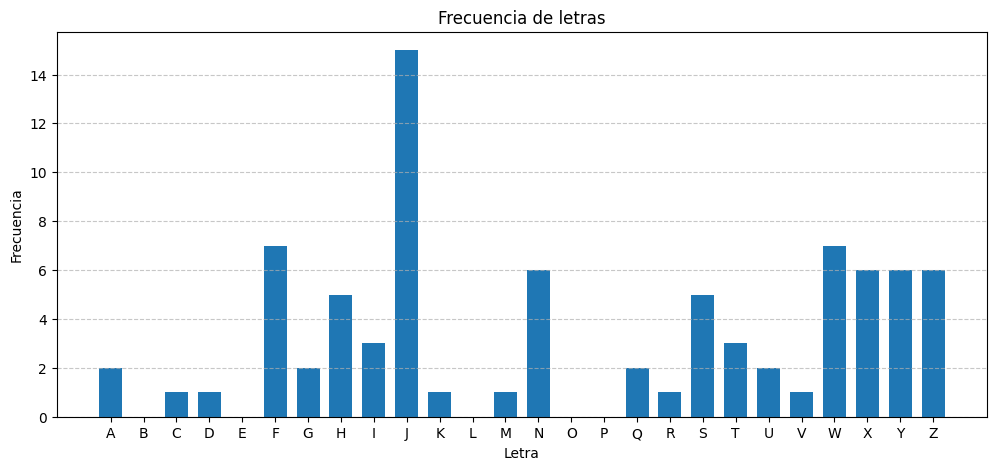

In [10]:
### Celda 8: Analisis de frecuencia de un texto cifrado

texto_usuario = "ESTE ES UN TEXTO DE PRUEBA QUE CONTIENE MUCHAS LETRAS Y SIRVE PARA VER LA DISTRIBUCION DE FRECUENCIA"#"Ingresa el texto que deseas cifrar: "
clave_usuario = 5 #"Ingresa el desplazamiento (clave) [0-25]: "

texto_cifrado_usuario = cifrado_cesar(texto_usuario, clave_usuario)

print("\nResultado:")
print(f"Texto cifrado  : {texto_cifrado_usuario}")

graficar_frecuencia(texto_cifrado_usuario)


In [12]:
#Celda 9: Análisis de frecuencia y obtención de la clave

from collections import Counter

# Texto cifrado a analizar
texto_cifrado = texto_cifrado_usuario  # Asegúrate que esta variable esté definida

# Contamos la frecuencia de cada letra
frecuencias = Counter([c for c in texto_cifrado.upper() if c.isalpha()])
letra_mas_comun = frecuencias.most_common(1)[0][0]

# Suponemos que la letra más común representa la 'E'
pos_letra_comun = ord(letra_mas_comun) - ord('A')
pos_E = ord('E') - ord('A')

clave_estimada = (pos_letra_comun - pos_E) % 26
print(f"Letra más común: {letra_mas_comun}")
print(f"Clave estimada: {clave_estimada}")

texto_descifrado = descifrado_cesar(texto_cifrado, clave_estimada)

# Mostrar resultado
print("\nTexto descifrado (estimado):")
print(texto_descifrado)


Letra más común: J
Clave estimada: 5

Texto descifrado (estimado):
ESTE ES UN TEXTO DE PRUEBA QUE CONTIENE MUCHAS LETRAS Y SIRVE PARA VER LA DISTRIBUCION DE FRECUENCIA


In [26]:

### Celda 4: Obtención de la clave mediante análisis de frecuencia

def obtener_clave_por_frecuencia(texto_cifrado):
    texto_cifrado = texto_cifrado.upper()
    letras_filtradas = [letra for letra in texto_cifrado if letra in ALPHABET]
    frecuencia = Counter(letras_filtradas)
    letra_mas_comun = frecuencia.most_common(1)[0][0]
    print(f"Letra más común en el texto cifrado: {letra_mas_comun}")

    # Suponemos que esta letra representa la 'E'
    desplazamiento = (ALPHABET.index(letra_mas_comun) - ALPHABET.index('E')) % 26
    print(f"Clave (desplazamiento) estimada: {desplazamiento}")
    return desplazamiento



clave = 2
texto_original = "ESTE ES UN TEXTO DE PRUEBA QUE CONTIENE MUCHAS LETRAS Y SIRVE PARA VER LA DISTRIBUCION DE FRECUENCIA"
cifrado = cifrado_cesar(texto_original, clave)


# Prueba con el texto cifrado anterior
clave_estimacion = obtener_clave_por_frecuencia(cifrado)
texto_descifrado_estimado = descifrado_cesar(cifrado, clave_estimacion)
print("Texto cifrado:")
print(cifrado)
print("Texto descifrado usando análisis de frecuencia:")
print(texto_descifrado_estimado)

Letra más común en el texto cifrado: G
Clave (desplazamiento) estimada: 2
Texto cifrado:
GUVG GU WP VGZVQ FG RTWGDC SWG EQPVKGPG OWEJCU NGVTCU A UKTXG RCTC XGT NC FKUVTKDWEKQP FG HTGEWGPEKC
Texto descifrado usando análisis de frecuencia:
ESTE ES UN TEXTO DE PRUEBA QUE CONTIENE MUCHAS LETRAS Y SIRVE PARA VER LA DISTRIBUCION DE FRECUENCIA


In [ ]:
### 🔍 Celda 10: Ataque de fuerza bruta

def fuerza_bruta(texto_cifrado):
    print("\nIntentos de descifrado por fuerza bruta:")
    for k in range(26):
        print(f"Clave {k:2d}: {descifrado_cesar(texto_cifrado, k)}")

# Para probar:
fuerza_bruta("KROD PXQGR")


Intentos de descifrado por fuerza bruta:
Clave  0: LQWURGXFFLRQ D OD FULSWRJUDILD
Clave  1: KPVTQFWEEKQP C NC ETKRVQITCHKC
Clave  2: JOUSPEVDDJPO B MB DSJQUPHSBGJB
Clave  3: INTRODUCCION A LA CRIPTOGRAFIA
Clave  4: HMSQNCTBBHNM Z KZ BQHOSNFQZEHZ
Clave  5: GLRPMBSAAGML Y JY APGNRMEPYDGY
Clave  6: FKQOLARZZFLK X IX ZOFMQLDOXCFX
Clave  7: EJPNKZQYYEKJ W HW YNELPKCNWBEW
Clave  8: DIOMJYPXXDJI V GV XMDKOJBMVADV
Clave  9: CHNLIXOWWCIH U FU WLCJNIALUZCU
Clave 10: BGMKHWNVVBHG T ET VKBIMHZKTYBT
Clave 11: AFLJGVMUUAGF S DS UJAHLGYJSXAS
Clave 12: ZEKIFULTTZFE R CR TIZGKFXIRWZR
Clave 13: YDJHETKSSYED Q BQ SHYFJEWHQVYQ
Clave 14: XCIGDSJRRXDC P AP RGXEIDVGPUXP
Clave 15: WBHFCRIQQWCB O ZO QFWDHCUFOTWO
Clave 16: VAGEBQHPPVBA N YN PEVCGBTENSVN
Clave 17: UZFDAPGOOUAZ M XM ODUBFASDMRUM
Clave 18: TYECZOFNNTZY L WL NCTAEZRCLQTL
Clave 19: SXDBYNEMMSYX K VK MBSZDYQBKPSK
Clave 20: RWCAXMDLLRXW J UJ LARYCXPAJORJ
Clave 21: QVBZWLCKKQWV I TI KZQXBWOZINQI
Clave 22: PUAYVKBJJPVU H SH JYPWAVNYHMPH
Clave 23: OTZXU